In [5]:
!pip install ultralytics


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ============================================================
# STEP 1: INITIALIZE ENVIRONMENT & DIRECTORIES
# ============================================================
import os
import shutil
from ultralytics import YOLO

In [7]:
# Define the paths based on Kaggle or local workspace
KAGGLE_INPUT_DIR = "/kaggle/input/datasets/vigneshnachu/industrial-hazards-detection"
LOCAL_INPUT_DIR = os.path.join(os.getcwd(), "industrial-hazards-detection")
INPUT_DIR = None
for candidate in [KAGGLE_INPUT_DIR, LOCAL_INPUT_DIR]:
    if os.path.isdir(candidate):
        INPUT_DIR = candidate
        break

if INPUT_DIR is None:
    raise FileNotFoundError(
        "Could not locate the industrial hazards dataset.\n"
        "Please download the dataset and place it in the workspace as 'industrial-hazards-detection',\n"
        "or update INPUT_DIR to point to the correct dataset directory.\n"
        f"Tried:\n  - {KAGGLE_INPUT_DIR}\n  - {LOCAL_INPUT_DIR}"
    )

WORKING_DIR = os.path.join(os.getcwd(), "cleaned_hazards_dataset")
print(f"Using INPUT_DIR = {INPUT_DIR}")
print(f"Using WORKING_DIR = {WORKING_DIR}")

print("Setting up directory structures...")
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(WORKING_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(WORKING_DIR, split, 'labels'), exist_ok=True)


FileNotFoundError: Could not locate the industrial hazards dataset.
Please download the dataset and place it in the workspace as 'industrial-hazards-detection',
or update INPUT_DIR to point to the correct dataset directory.
Tried:
  - /kaggle/input/datasets/vigneshnachu/industrial-hazards-detection
  - c:\Users\Dell Precision 7520\Desktop\Construction-Safety-Hazard-Detection\industrial-hazards-detection

In [ ]:
print("Processing data layers and dropping 'no helmet' instances...")

TARGET_DROP_ID = 2  # 'no helmet' index

# Loop through the two existing dataset directories
for split in ['train', 'valid']:
    raw_labels_path = os.path.join(INPUT_DIR, split, 'labels')
    raw_images_path = os.path.join(INPUT_DIR, split, 'images')

    # Fallback for alternate directory naming if needed
    if not os.path.isdir(raw_labels_path):
        alternate_labels = os.path.join(INPUT_DIR, f"{split}_labels")
        if os.path.isdir(alternate_labels):
            raw_labels_path = alternate_labels

    if not os.path.isdir(raw_images_path):
        alternate_images = os.path.join(INPUT_DIR, f"{split}_images")
        if os.path.isdir(alternate_images):
            raw_images_path = alternate_images

    if not os.path.isdir(raw_labels_path) or not os.path.isdir(raw_images_path):
        raise FileNotFoundError(
            f"Could not find labels or images for split '{split}' in {INPUT_DIR}.\n"
            f"Expected paths:\n  - {raw_labels_path}\n  - {raw_images_path}"
        )

    for filename in os.listdir(raw_labels_path):
        if filename.endswith(".txt"):
            # 1. Read the original annotation data
            with open(os.path.join(raw_labels_path, filename), "r") as f:
                lines = f.readlines()
            
            cleaned_lines = []
            for line in lines:
                parts = line.split()
                if not parts:
                    continue
                
                class_id = int(parts[0])
                
                # Drop condition met: skip line execution
                if class_id == TARGET_DROP_ID:
                    continue
                
                # Shift mapping logic down for classes above the dropped index
                if class_id > TARGET_DROP_ID:
                    new_class_id = class_id - 1
                else:
                    new_class_id = class_id

                parts[0] = str(new_class_id)
                cleaned_lines.append(" ".join(parts) + "\n")
            
            # 2. Write the cleaned label file
            with open(os.path.join(WORKING_DIR, split, 'labels', filename), "w") as f:
                f.writelines(cleaned_lines)

            # 3. Copy the matching image file to the new directory
            img_filename = filename.replace(".txt", ".jpg")
            src_img = os.path.join(raw_images_path, img_filename)
            dest_img = os.path.join(WORKING_DIR, split, 'images', img_filename)
            if os.path.exists(src_img):
                shutil.copy(src_img, dest_img)

print("Dataset cleaning complete! All index tags shifted successfully.")

Processing data layers and dropping 'no helmet' instances...


FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/datasets/vigneshnachu/industrial-hazards-detection/train/labels'

In [ ]:

# ============================================================
# STEP 3: DYNAMICALLY CREATE THE NEW data.yaml
# ============================================================
yaml_content = f"""
path: {WORKING_DIR}
train: train/images
val: valid/images

nc: 4
names:
  0: chemical hazard
  1: fire
  2: smoke
  3: water leak
"""

yaml_file_path = os.path.join(os.getcwd(), "data_hazards.yaml")
with open(yaml_file_path, "w") as f:
    f.write(yaml_content.strip())

print(f"New configuration file generated at: {yaml_file_path}")

New configuration file generated at: /kaggle/working/data_hazards.yaml


In [10]:
# ============================================================
# STEP 4: INITIALIZE MODEL & OPTIMIZED TRAINING
# ============================================================
print("Loading YOLOv8s Architecture weights...")
model = YOLO("yolov8s.pt")

print("Launching model training pipeline on GPU...")
results = model.train(
    data=yaml_file_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,          
    workers=2,
    optimizer="AdamW",
    lr0=0.005,         
    patience=15,       
    project="Industrial_hazards",
    name="yolov8s_industrial_hazards",
    cache=False,
    
    # --- Weighting & Loss Tweaks ---
    cls=1.5,                    # Tripled classification focus to boost individual class mAP
    
    # --- Structural Augmentations ---
    mosaic=1.0,        
    mixup=0.15,        
    scale=0.6          
)

print("Training cycle successfully completed!")

Loading YOLOv8s Architecture weights...
Launching model training pipeline on GPU...
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_hazards.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_indust

In [ ]:
import os
import zipfile

def zip_folder(folder_path, output_zip_path):
    print(f"Starting compression of: {folder_path}")
    with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                # Create the relative path inside the zip file
                absolute_path = os.path.join(root, file)
                relative_path = os.path.relpath(absolute_path, folder_path)
                zipf.write(absolute_path, relative_path)
    print(f"Success! Compressed archive created at: {output_zip_path}")

# --- DEFINE YOUR TARGETS ---
TARGET_FOLDER = WORKING_DIR
OUTPUT_ZIP = os.path.join(os.getcwd(), "cleaned_hazards_dataset.zip")

# Execute the zip function
zip_folder(TARGET_FOLDER, OUTPUT_ZIP)

Starting compression of: /kaggle/working/cleaned_hazards_dataset
Success! Compressed archive created at: /kaggle/working/cleaned_hazards_dataset.zip



--- Displaying confusion_matrix.png ---


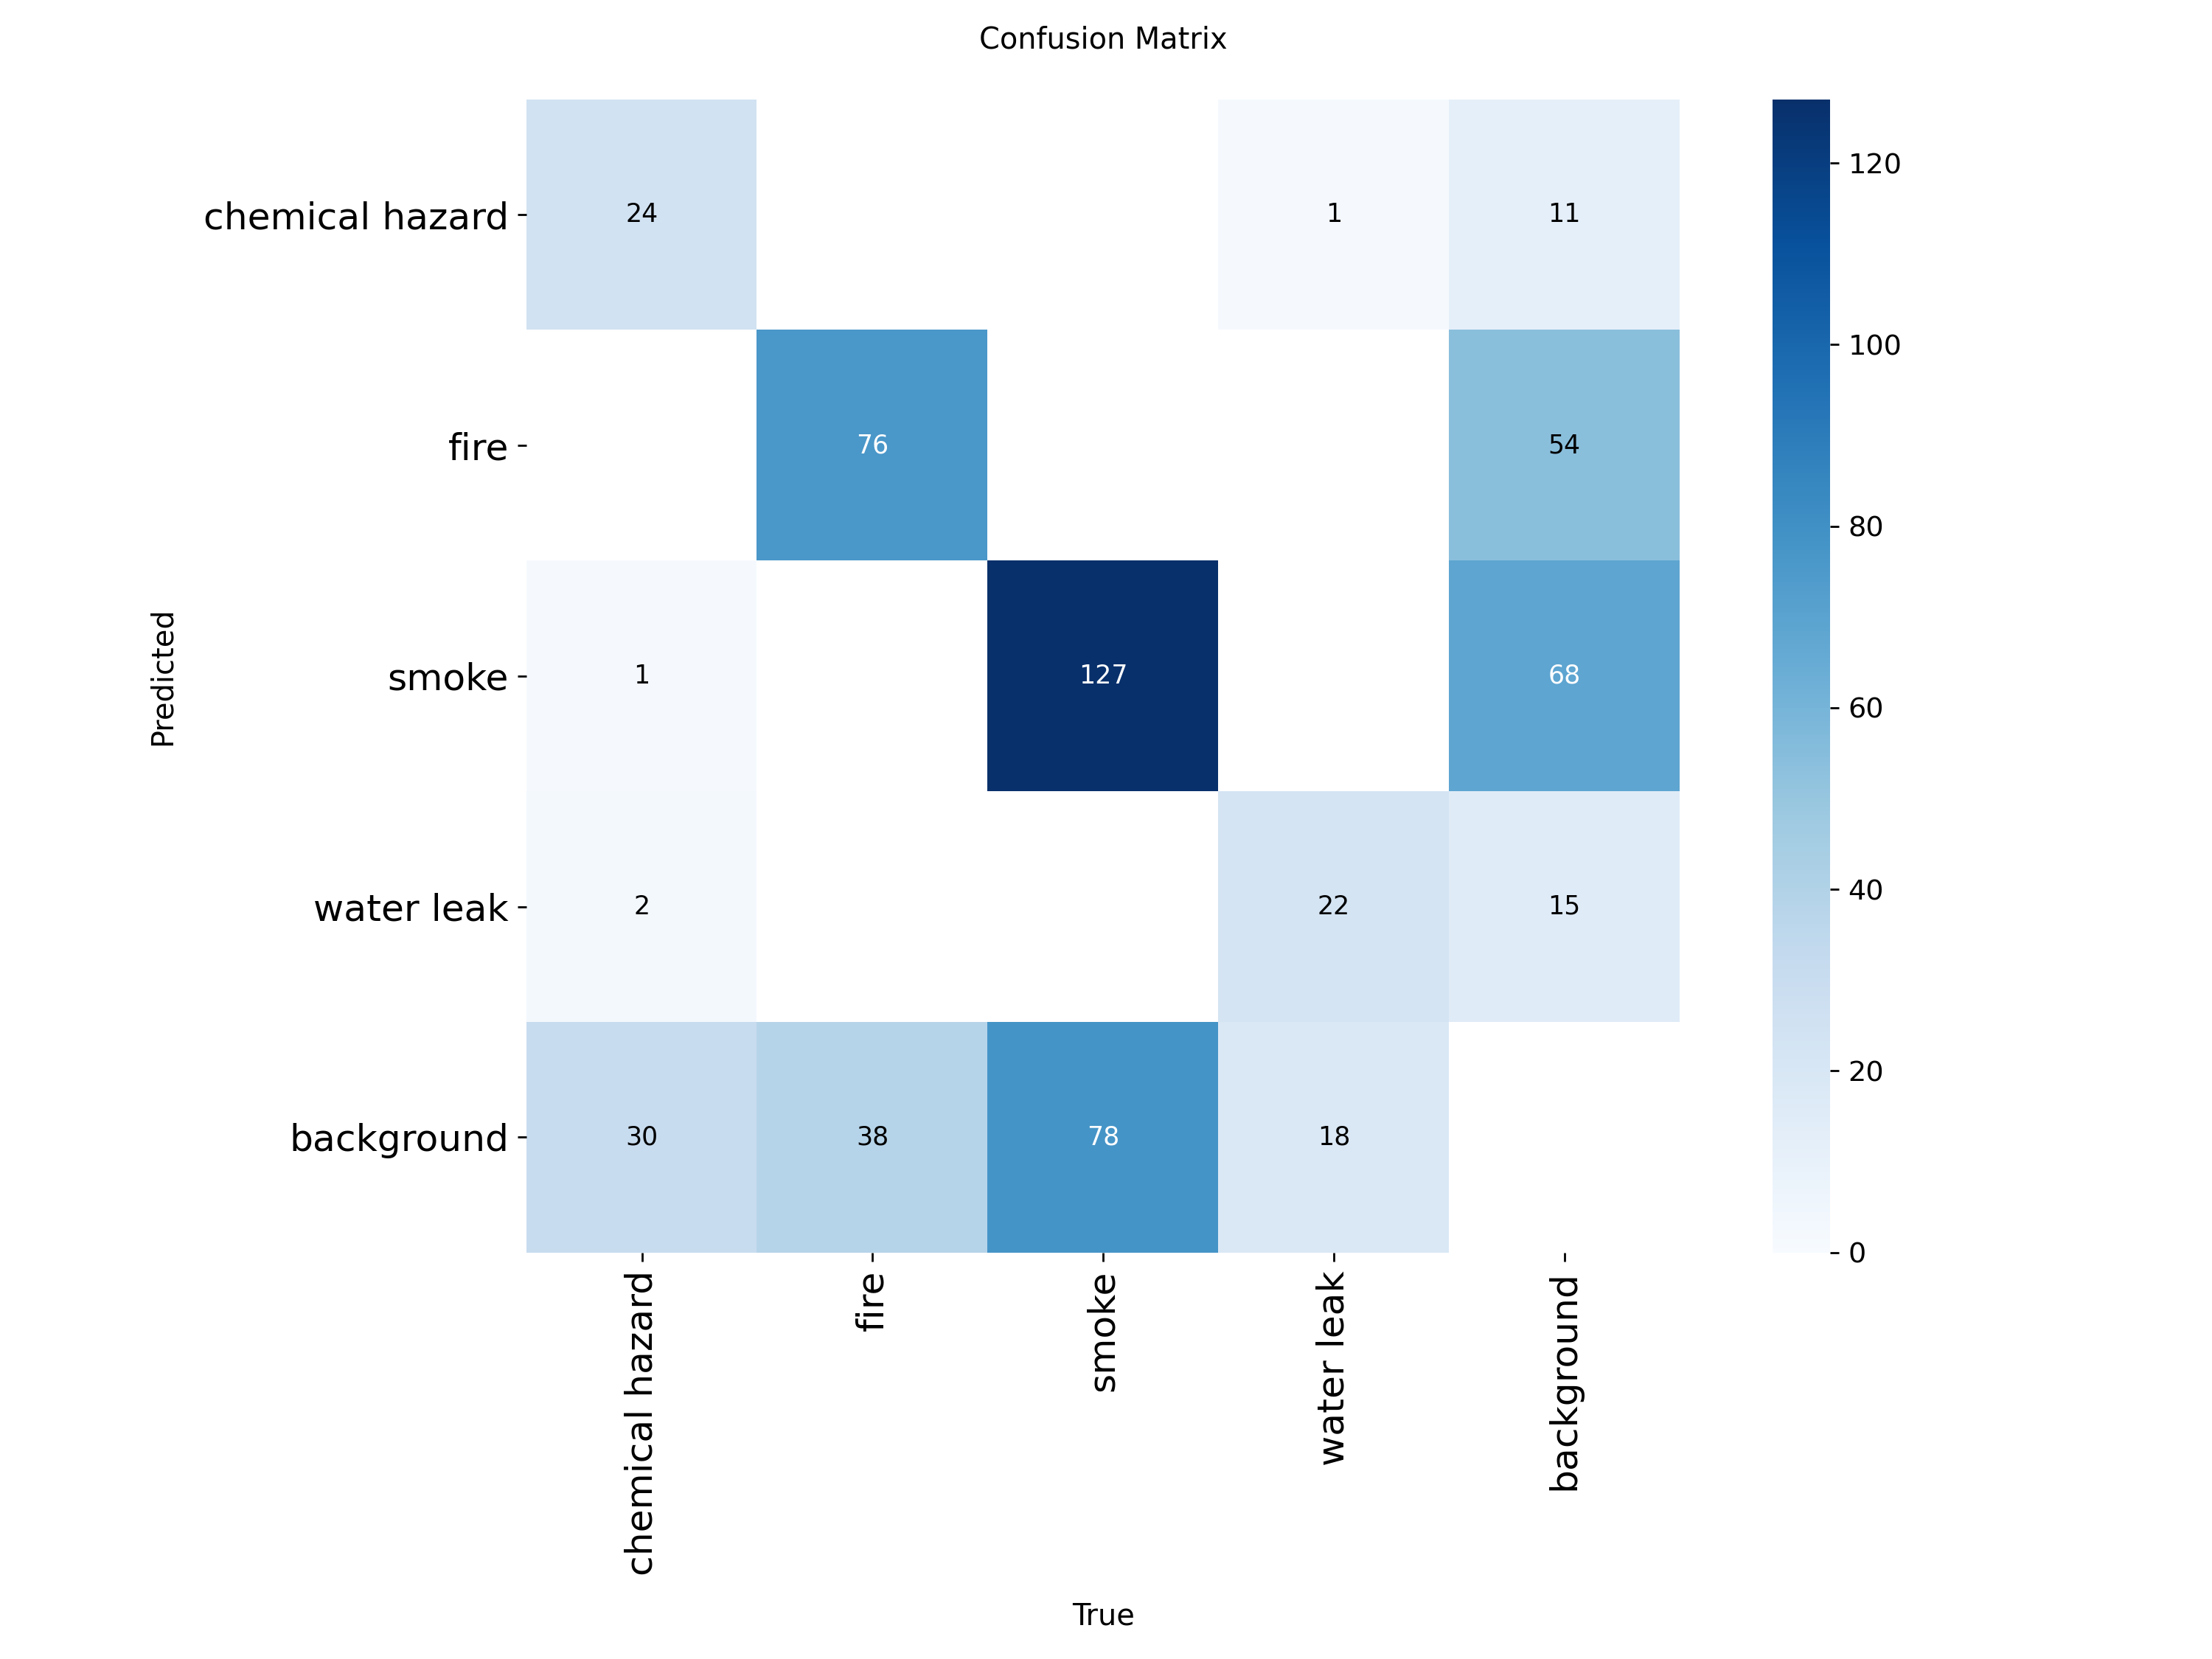


--- Displaying BoxF1_curve.png ---


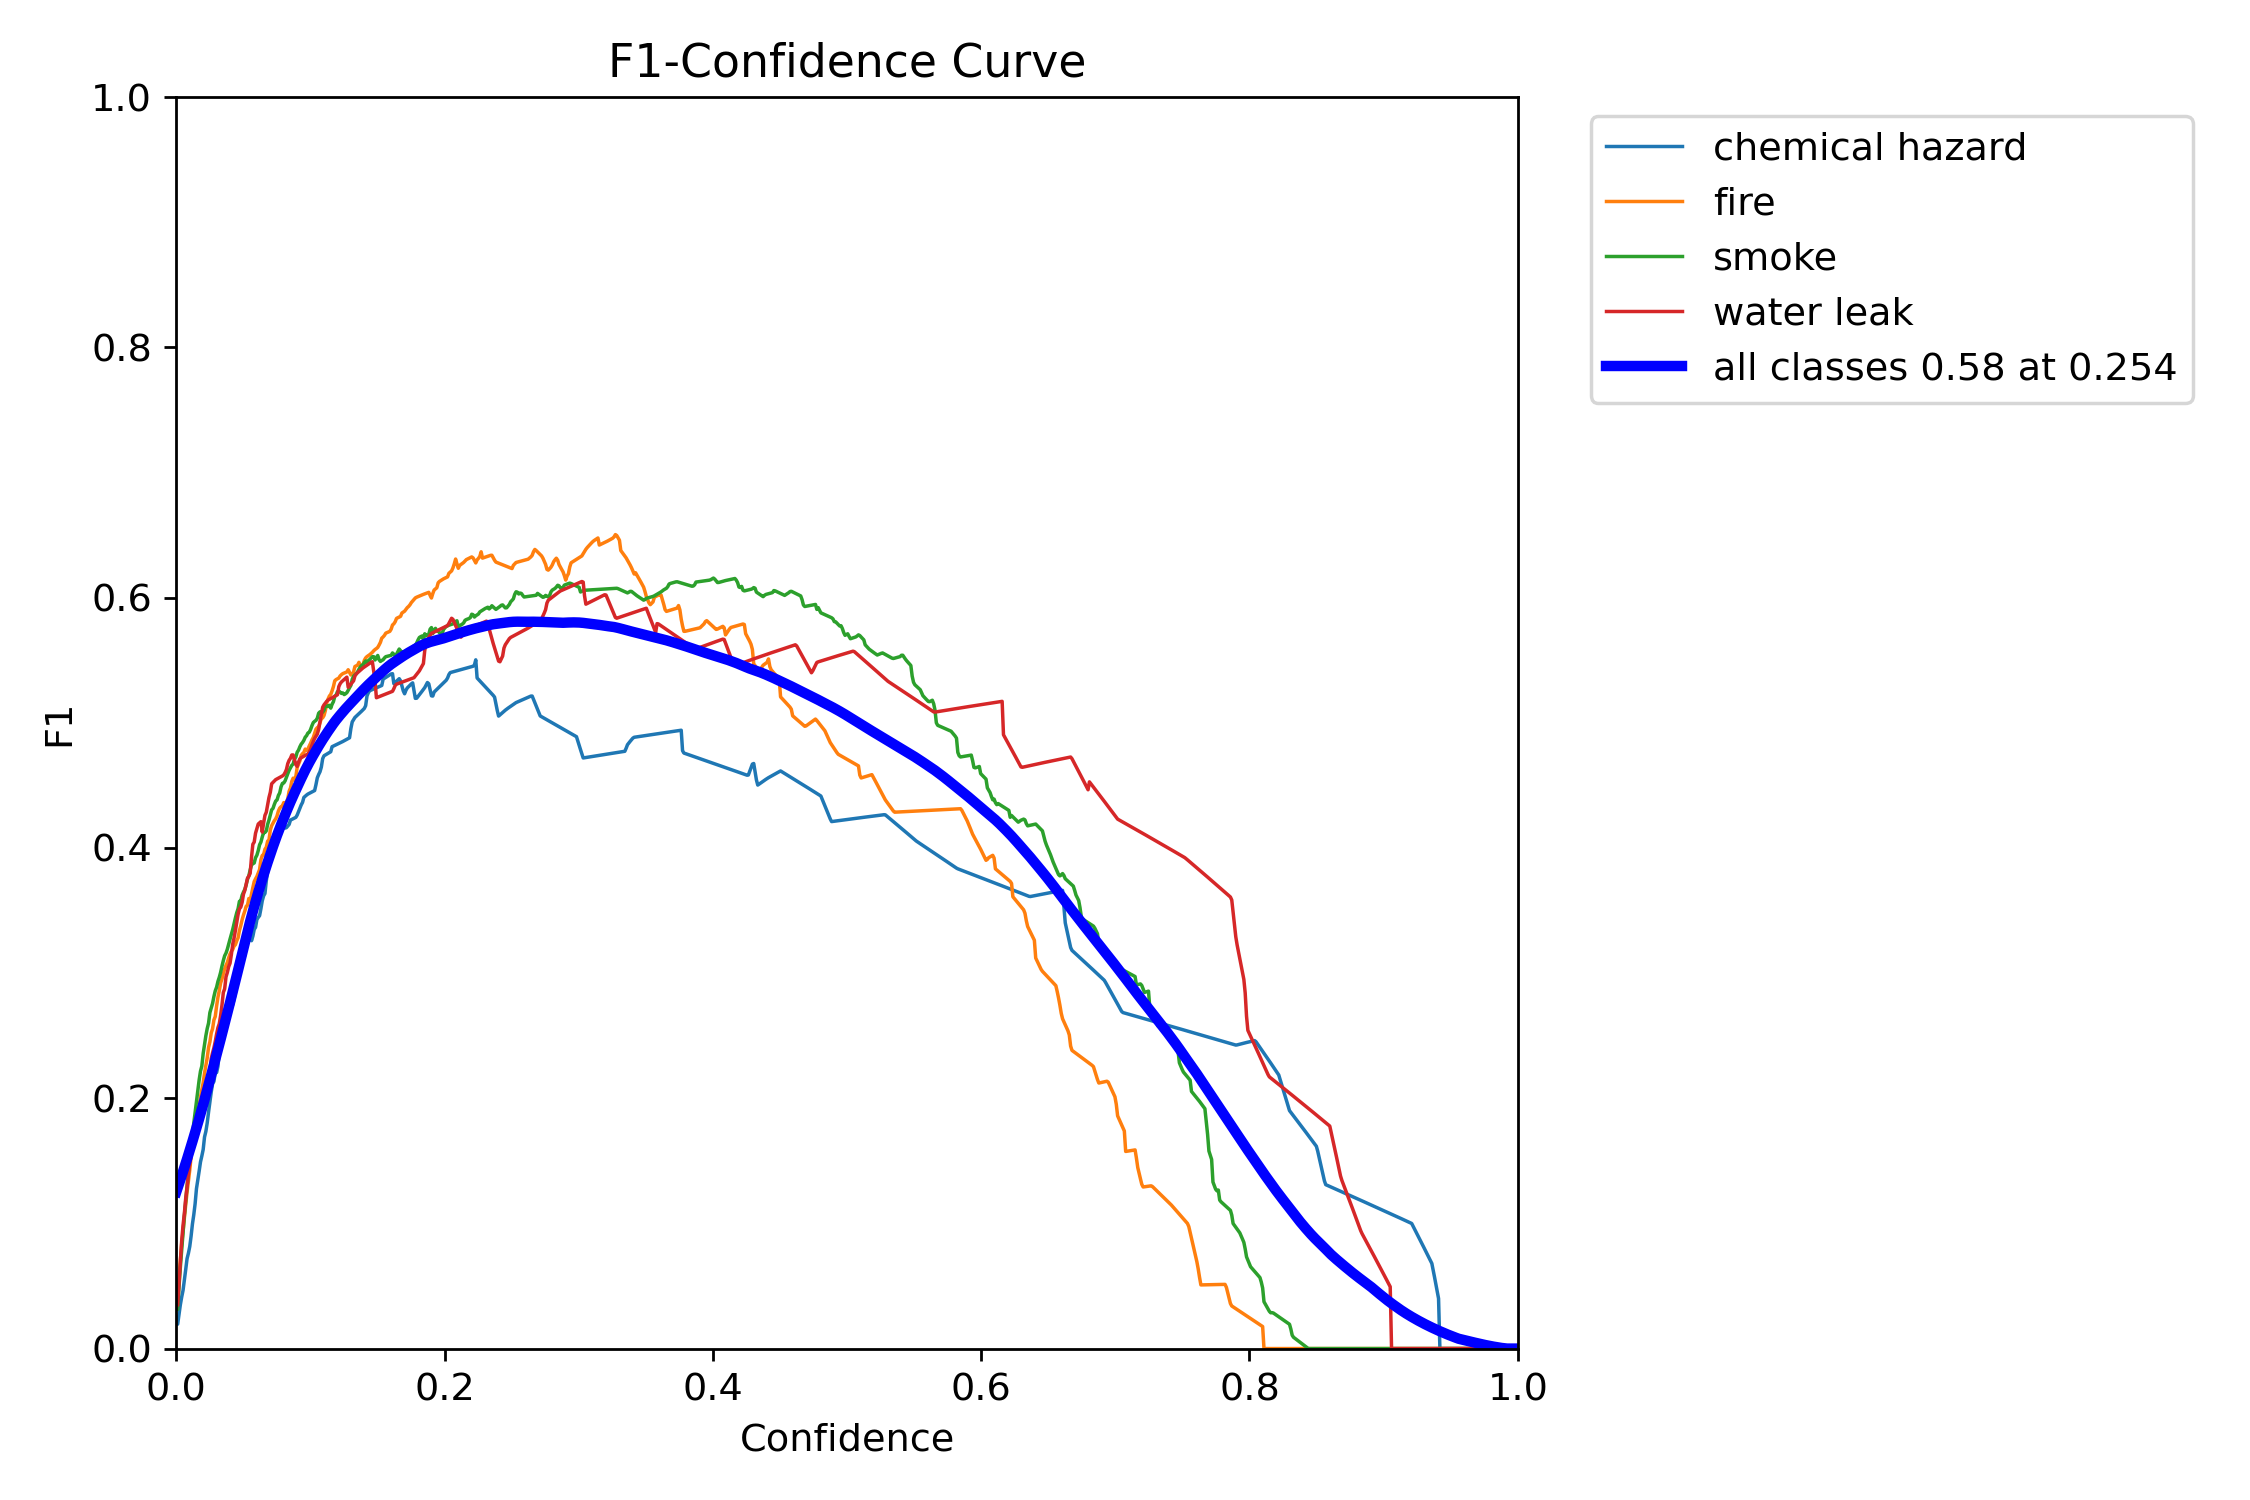


--- Displaying BoxPR_curve.png ---


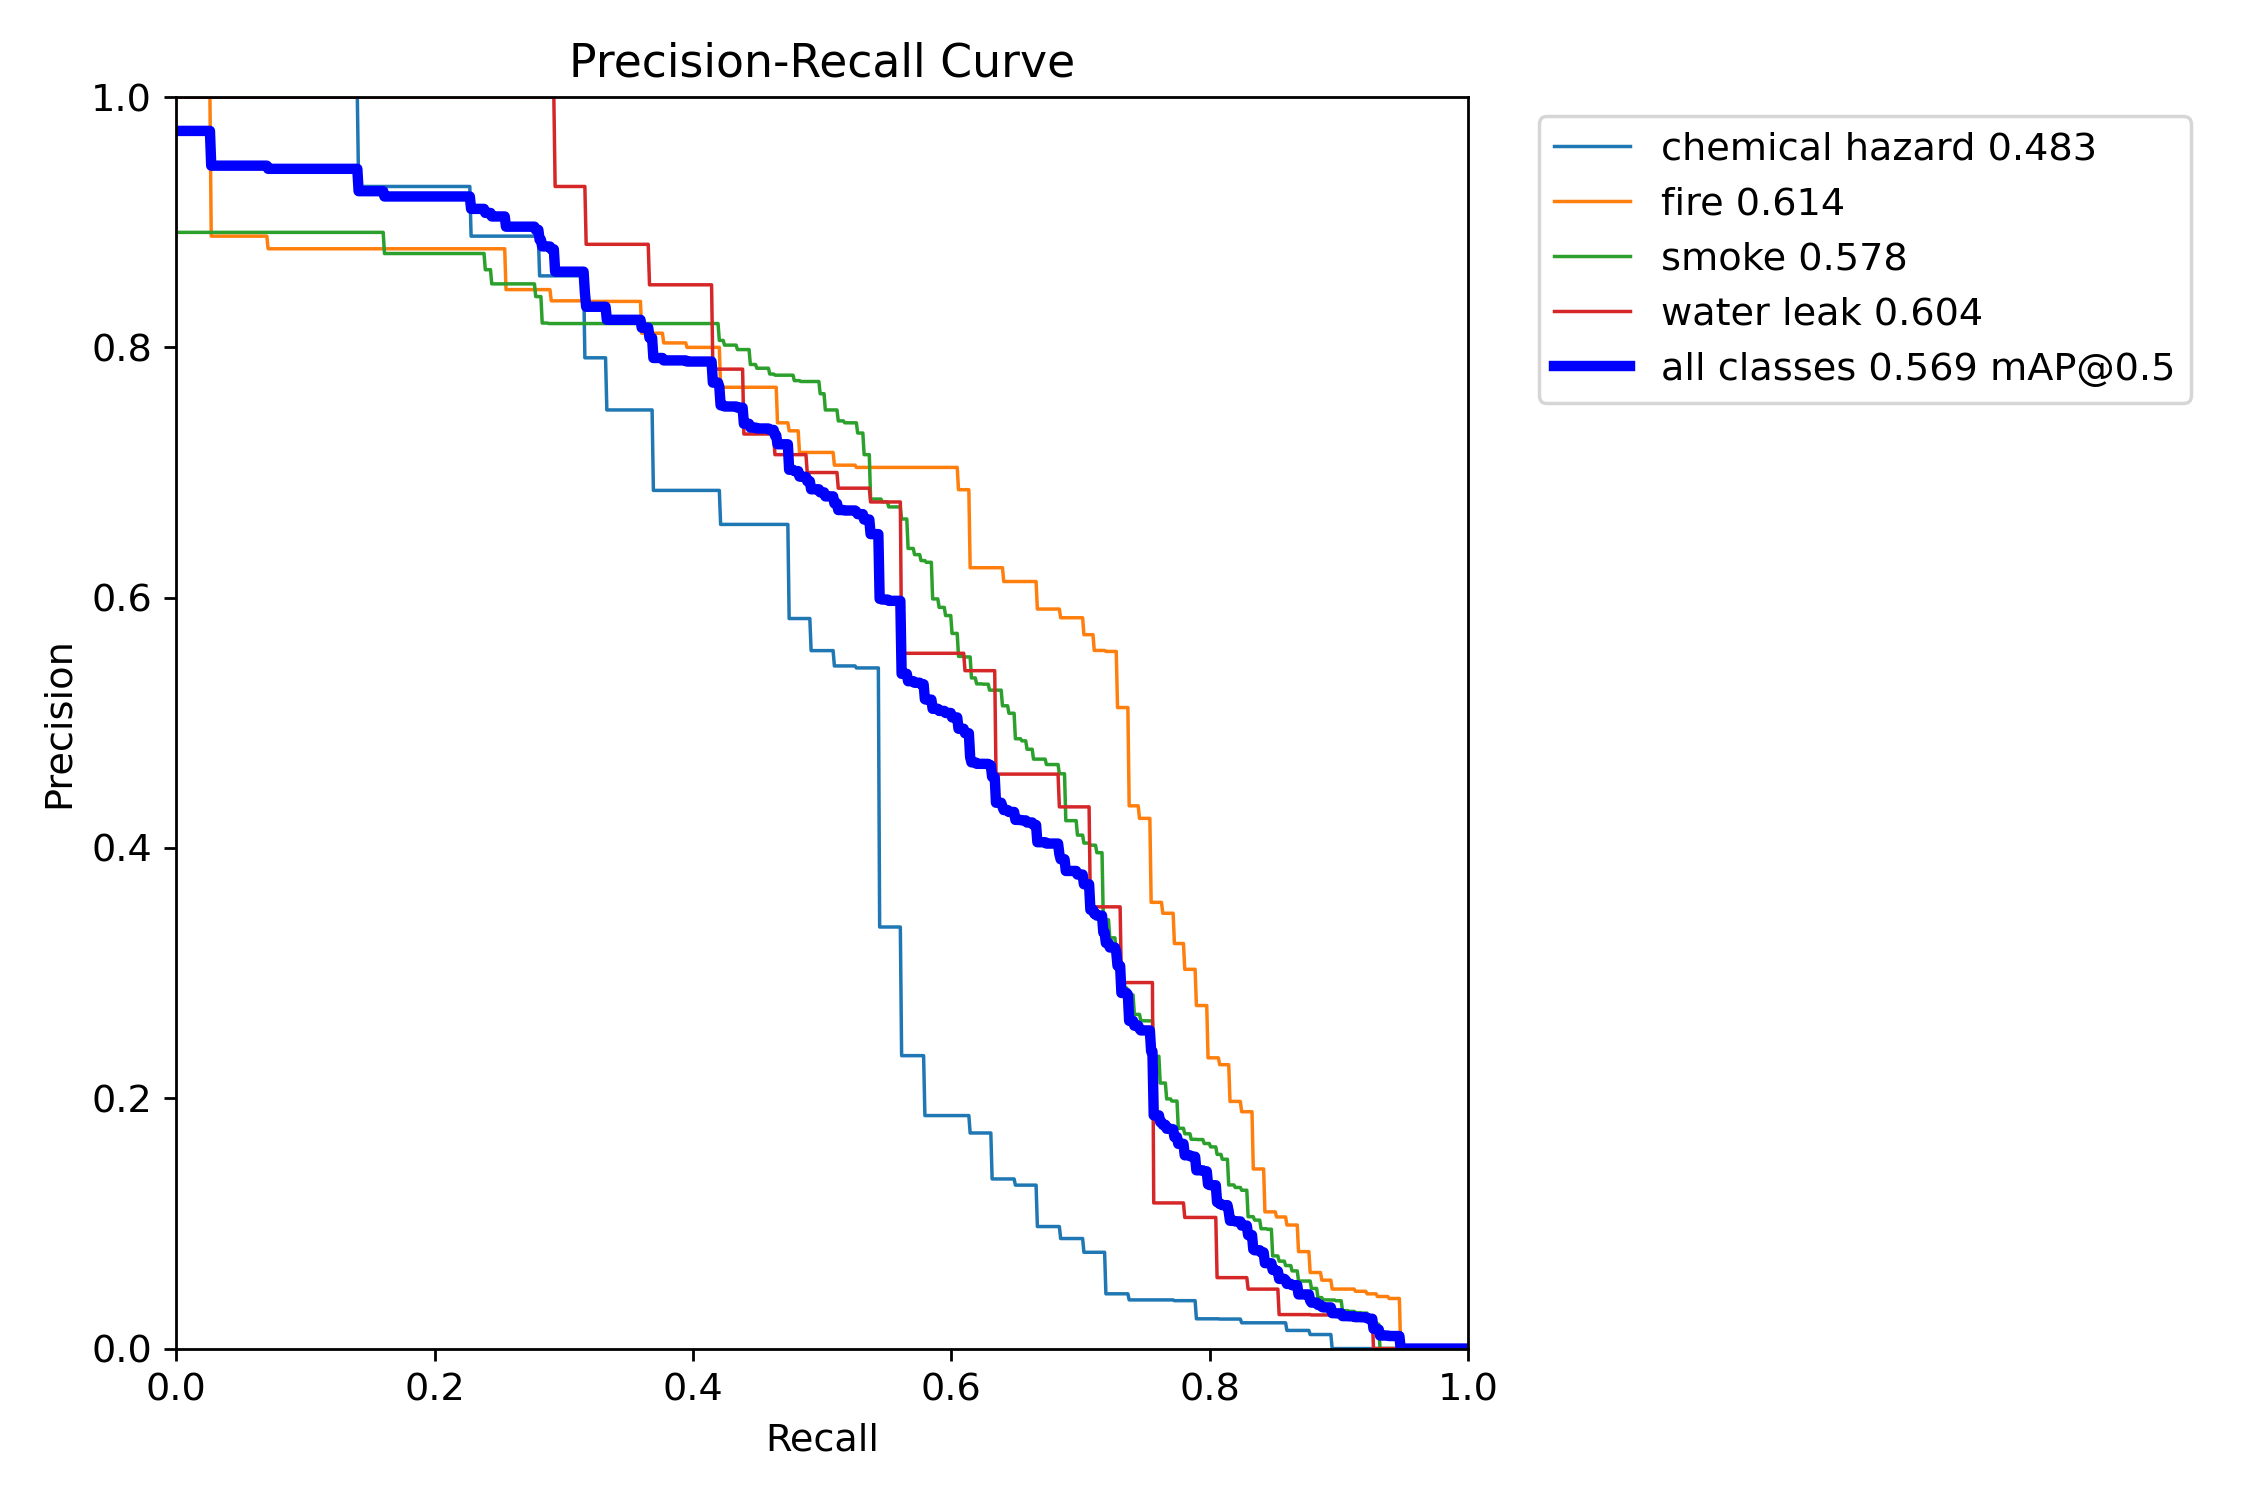

In [ ]:
import glob
import IPython.display as display
import os

runs_base_dir = os.path.join(os.getcwd(), "runs", "detect", "Industrial_hazards")
runs_dir = None
if os.path.isdir(runs_base_dir):
    run_dirs = sorted(
        glob.glob(os.path.join(runs_base_dir, "yolov8s_industrial_hazards*")),
        key=os.path.getmtime,
    )
    if run_dirs:
        runs_dir = run_dirs[-1]


if runs_dir is None:        display.display(display.Image(filename=chart_path))

    runs_dir = os.path.join(runs_base_dir, "yolov8s_industrial_hazards-2")        print(f"\n--- Displaying {chart} ---")

    if os.path.exists(chart_path):

# List of target summary charts to print to your screen    chart_path = os.path.join(runs_dir, chart)

charts = ["confusion_matrix.png", "BoxF1_curve.png", "BoxPR_curve.png",]for chart in charts:
